In [27]:
import cupy as cp
import math
import matplotlib.pyplot as plt
from model.network import Network


## Loading the Data

In [28]:
training_path = "input/training.txt"
validation_path = "input/validation.txt"

with open(training_path, "r", encoding="utf-8") as file:
    training_data = file.read()

with open(validation_path, "r", encoding="utf-8") as file:
    validation_data = file.read()

training_data = list(training_data)
validation_data = list(validation_data)

x_train = training_data[:-1]
y_train = training_data[1:]

x_test = validation_data[:-1]
y_test = validation_data[1:]

print(f"Training data length: X={len(x_train)}, Y={len(y_train)}")
print(f"Validation data length: X={len(x_test)}, Y={len(y_test)}")

Training data length: X=880791, Y=880791
Validation data length: X=234596, Y=234596


In [29]:
vocabulary = sorted(set(training_data).union(set(validation_data)))
print(f"Vocabulary size: {len(vocabulary)}")

Vocabulary size: 65


In [30]:
def char_to_index(char: str) -> int:
    return vocabulary.index(char)

def index_to_char(index: int) -> str:
    return vocabulary[index]

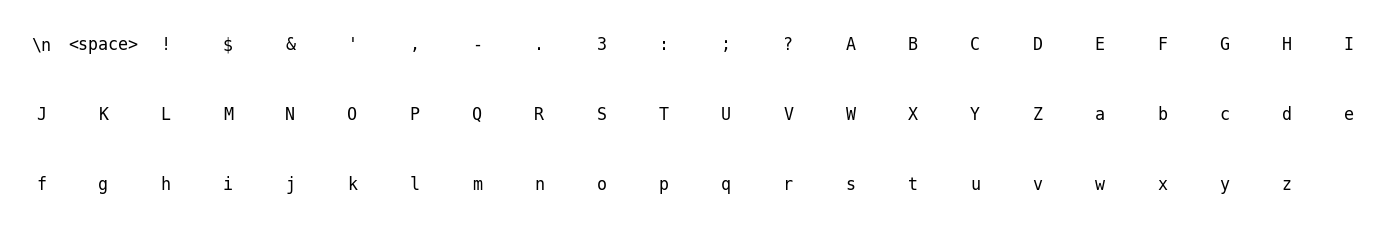

In [31]:
cols = 22
rows = math.ceil(len(vocabulary) / cols)

fig, ax = plt.subplots(figsize=(14, max(2, rows * 0.8)))

for index, token in enumerate(vocabulary):
    row, col = divmod(index, cols)
    display_token = {" ": "<space>", "\n": "\\n", "\t": "\\t"}.get(token, token)
    y = rows - row - 1
    ax.text(col, y, display_token, ha="center", va="center", fontsize=12, family="monospace")

ax.set_xlim(-0.5, cols - 0.5)
ax.set_ylim(-0.5, rows - 0.5)
ax.set_xticks(range(cols))
ax.set_yticks(range(rows))
ax.grid(True, linestyle=":", alpha=0.3)
plt.axis("off")
plt.tight_layout()
plt.show()

In [32]:
x_train_indices = cp.asarray([char_to_index(char) for char in x_train], dtype=cp.int32)
y_train_indices = cp.asarray([char_to_index(char) for char in y_train], dtype=cp.int32)
x_test_indices = cp.asarray([char_to_index(char) for char in x_test], dtype=cp.int32)
y_test_indices = cp.asarray([char_to_index(char) for char in y_test], dtype=cp.int32)

## Building the Model

In [33]:
embedding_dim = 64
hidden_size = 256
hidden_2_size = 128

layer_definitions = [
    {"type": "Embedding", "num_embeddings": len(vocabulary), "embedding_dim": embedding_dim},
    {"type": "GatedRecurrent", "input_size": embedding_dim, "num_neurons": hidden_size},
    {"type": "GatedRecurrent", "input_size": hidden_size, "num_neurons": hidden_2_size},
    {"type": "Softmax", "input_size": hidden_2_size, "num_neurons": len(vocabulary)},
]

network = Network(layer_definitions=layer_definitions)
network.describe()


Network Architecture

Layer 1: EmbeddingLayer
  Embeddings Shape: (65, 64)
  Parameters: 4,160

Layer 2: GatedRecurrentLayer
  Weights Shape: (64, 256) | Recurrent Weights Shape: (256, 256) | Gates: 3
  Parameters: 246,528

Layer 3: GatedRecurrentLayer
  Weights Shape: (256, 128) | Recurrent Weights Shape: (128, 128) | Gates: 3
  Parameters: 147,840

Layer 4: SoftmaxLayer
  Weights Shape: (128, 65) | Biases Shape: (65,)
  Parameters: 8,385

Total Parameters: 406,913


## Training the Model

In [34]:
def one_hot(indices: cp.ndarray, num_classes: int) -> cp.ndarray:
    encoded = cp.zeros((indices.shape[0], num_classes), dtype=cp.float32)
    encoded[cp.arange(indices.shape[0]), indices] = 1.0
    return encoded

In [35]:
def reshape_streams(
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    max_columns: int | None = None,
 ) -> tuple[cp.ndarray, cp.ndarray]:
    usable_tokens = (x_indices.shape[0] // batch_size) * batch_size
    x = x_indices[:usable_tokens].reshape(batch_size, -1)
    y = y_indices[:usable_tokens].reshape(batch_size, -1)

    if max_columns is not None:
        x = x[:, :max_columns]
        y = y[:, :max_columns]

    return x, y

In [36]:
def evaluate(
    network: Network,
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    sequence_length: int,
    max_steps: int | None = None,
) -> float:
    x, y = reshape_streams(
        x_indices=x_indices,
        y_indices=y_indices,
        batch_size=batch_size,
        max_columns=max_steps,
    )

    network.reset_states(batch_size=batch_size, dtype=cp.float32)
    total_loss = 0.0
    total_steps = x.shape[1]

    for step in range(total_steps):
        y_prob = network.forward(x[:, step])[-1]
        y_true = one_hot(y[:, step], len(vocabulary))
        total_loss += float(network.cce_loss(y_prob, y_true).item())

        if (step + 1) % sequence_length == 0:
            network.reset_states(batch_size=batch_size, dtype=cp.float32)

    return math.exp(total_loss / total_steps)


In [37]:
def train_epoch(
    network: Network,
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    sequence_length: int,
    learning_rate: float,
    max_steps: int | None = None,
    weight_decay_lambda: float = 0.0,
    momentum: float = 0.0,
) -> float:
    x, y = reshape_streams(
        x_indices=x_indices,
        y_indices=y_indices,
        batch_size=batch_size,
        max_columns=max_steps,
    )
    network.reset_states(batch_size=batch_size, dtype=cp.float32)
    total_loss = 0.0
    total_steps = x.shape[1]

    for chunk_start in range(0, total_steps, sequence_length):
        chunk_end = min(chunk_start + sequence_length, total_steps)
        output_errors = []

        for step in range(chunk_start, chunk_end):
            y_prob = network.forward(x[:, step])[-1]
            y_true = one_hot(y[:, step], len(vocabulary))
            total_loss += float(network.cce_loss(y_prob, y_true).item())
            output_errors.append(y_prob - y_true)

        network.backward_sequence(output_errors, batch_size)
        network.update_parameters(learning_rate, weight_decay_lambda, momentum)
        network.reset_states(batch_size=batch_size, dtype=cp.float32)

    return math.exp(total_loss / total_steps)

In [38]:
sequence_length = 128
batch_size = 64
epochs = 500
train_steps_per_epoch = 3072
validation_steps = 1024
base_learning_rate = 0.05
min_learning_rate = 0.0005
weight_decay_lambda = 1e-4
momentum = 0.9
early_stopping_patience = 25

In [39]:
epoch_summaries = []

total_steps = epochs * train_steps_per_epoch
global_step = 0

best_model = None
best_perplexity = float("inf")
epochs_without_improvement = 0

for epoch in range(1, epochs + 1):
    learning_rate = min_learning_rate + 0.5 * (base_learning_rate - min_learning_rate) * (1 + math.cos(math.pi * global_step / total_steps))

    train_perplexity = train_epoch(
        network=network,
        x_indices=x_train_indices,
        y_indices=y_train_indices,
        batch_size=batch_size,
        sequence_length=sequence_length,
        learning_rate=learning_rate,
        max_steps=train_steps_per_epoch,
        weight_decay_lambda=weight_decay_lambda,
        momentum=momentum,
    )
    test_perplexity = evaluate(
        network=network,
        x_indices=x_test_indices,
        y_indices=y_test_indices,
        batch_size=batch_size,
        sequence_length=sequence_length,
        max_steps=validation_steps,
    )

    epoch_summary = {
        "epoch": epoch,
        "learning_rate": learning_rate,
        "train_perplexity": train_perplexity,
        "test_perplexity": test_perplexity,
    }
    epoch_summaries.append(epoch_summary)

    if epoch % 50 == 0 or epoch == 1:
        print(epoch_summary)

    if test_perplexity < best_perplexity:
        best_perplexity = test_perplexity
        best_model = network.clone()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    global_step += train_steps_per_epoch

    if epochs_without_improvement >= early_stopping_patience:
        print(f"Early stopping triggered after {epoch} epochs due to no improvement.")
        break


{'epoch': 1, 'learning_rate': 0.05, 'train_perplexity': 21.52461684765532, 'test_perplexity': 14.675420432111402}
{'epoch': 50, 'learning_rate': 0.048836238702551174, 'train_perplexity': 4.699658451958308, 'test_perplexity': 5.147617958985823}
{'epoch': 100, 'learning_rate': 0.045364180569719074, 'train_perplexity': 3.916560526415272, 'test_perplexity': 4.74816057565779}
Early stopping triggered after 141 epochs due to no improvement.


In [46]:
print(f"Best validation perplexity: {best_perplexity:.4f} at epoch {epoch - epochs_without_improvement}")

Best validation perplexity: 4.7293 at epoch 116


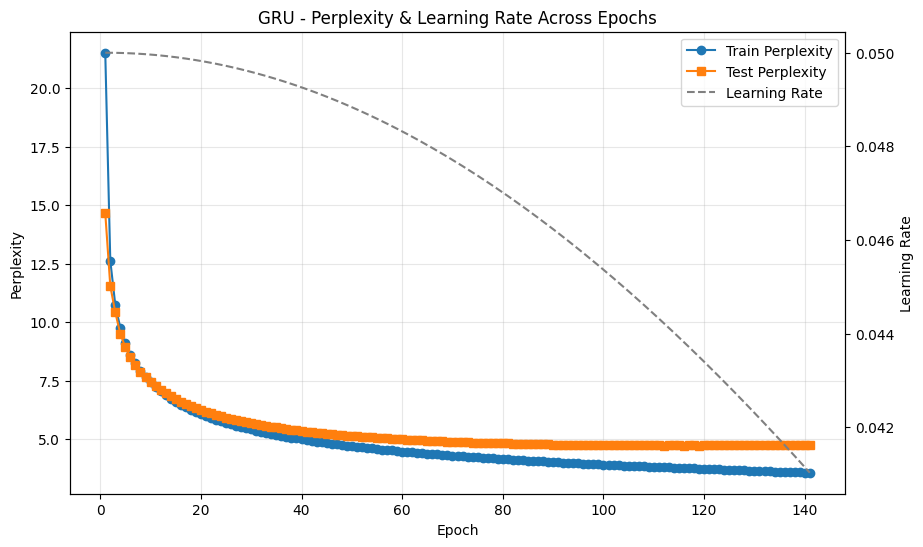

In [40]:
epochs_plot = [summary["epoch"] for summary in epoch_summaries]
train_perplexities = [summary["train_perplexity"] for summary in epoch_summaries]
test_perplexities = [summary["test_perplexity"] for summary in epoch_summaries]
learning_rates = [summary["learning_rate"] for summary in epoch_summaries]

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(epochs_plot, train_perplexities, marker="o", label="Train Perplexity")
ax1.plot(epochs_plot, test_perplexities, marker="s", label="Test Perplexity")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Perplexity")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(epochs_plot, learning_rates, color="gray", linestyle="--", linewidth=1.5, label="Learning Rate")
ax2.set_ylabel("Learning Rate")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.title("GRU - Perplexity & Learning Rate Across Epochs")
plt.show()

In [41]:
def generate_text(
    network: Network,
    seed_text: str,
    length: int = 250,
    temperature: float = 0.8,
    print_during: bool = True,
) -> str:
    network.reset_states(batch_size=1, dtype=cp.float32)
    generated = list(seed_text)

    if print_during:
        print(seed_text, end="")

    for character in seed_text:
        token_index = cp.asarray([char_to_index(character)], dtype=cp.int32)
        network.forward(token_index)

    current_character = seed_text[-1]

    for _ in range(length):
        token_index = cp.asarray([char_to_index(current_character)], dtype=cp.int32)
        y_prob = network.forward(token_index)[-1][0]
        log_prob = cp.log(y_prob + 1e-9) / temperature
        scaled_prob = cp.exp(log_prob - cp.max(log_prob))
        scaled_prob = scaled_prob / cp.sum(scaled_prob)
        next_index = int(
            cp.random.choice(len(vocabulary), size=1, p=scaled_prob)[0].item()
        )
        current_character = index_to_char(next_index)
        generated.append(current_character)

        if print_during:
            print(current_character, end="", flush=True)

    return "".join(generated)

In [42]:
seed_text = "DANIEL"
generated = generate_text(network=network, seed_text=seed_text, length=1000, temperature=0.9, print_during=True)

DANIELO:

Nurself:
Befork me with stoudest gabble fatch'd
And hay so prodates, for hrew remiss
in whines doth his parts and true; I had of the malived
and my honour pleasure of his asleed
Our valeant have servenders.

NORTHUMBERLAND:
Be unto you, let me Harp live,
He fleed to piece her where their worst his tread makest the death
Sholity hate and may be her.

CORIOLANUS:
I not found Angelo
Where I mee to hudger, I crave hide as it it!

Second Murder.

Second Juliet,
Yet, I say, the shall be your elease
And deeds it that I would it presently,
To make the personer's gods shalt 'em.

LEONTES:
Sir, thou not becaster,
And I will not with's business come.
Then Angelo, which have to ingeal? me a scorgbred judgment.

LUCUS:
They man that I, my love my tiff.

First Sorrow, no shrift your chance which
Edward in help the godss him; former temp't.

JULIET:
So sulp thou shall be gone all time: there's like the side,
She is not a word, and you have no man.

WARWICK:
Why, whose had your whatter not p

In [43]:
seed_text = "DANIEL"
generated = generate_text(network=network, seed_text=seed_text, length=1000, temperature=0.7, print_during=True)

DANIELO:
How could strongs go fast with the closed,
And do my son is this right of a little my sons.

LUCIO:
Nay, bechanded my foeth, and free your soul
To king of thy nexthell, and brought them and.

BAPTISTA:
A words of our spired that but a words
As goodly was in a that hap. But the plaintage me go spent,
Which boyart up your house of his faults.

POLIcHARRAND:
And but not heart of the least
I will be this in thy such a word.

CLIFFORD:
No, if thou wilt be again this for husband.

KING EDWARD:
I could have we will stand to execution the creant
The shrift the father and their dear guilty them
Extiments of pleased to them,
That I must Capurest, and when I must here of help,
And they have down the pains a man
Abhorrows' forgot my brother deep
And she house of heart and with that trumpething,
Who hast and home, thither wittended thy man
At do you heart with this faint, like the man.

SICINIUS:
Not thou dost thoughts that a day?

Third who is a pitch'd,
If not to a good and deserved,
And

In [44]:
seed_text = "DANIEL"
generated = generate_text(network=network, seed_text=seed_text, length=1000, temperature=0.5, print_during=True)

DANIELO:
Nay, be this in our warp and stands and here
now till the parting the first presently,
I know the seatend to my most charged and death.

KING RICHARD III:
O think the gates a black and banish'd and makes me and end
And that thou wilt thou hast thou hast banish'd
Which thou shall upon me, indeed.

BRUTUS:
The good lords to be with me the battle hearing the world
it and thy cause to his many earth.
I have mercy to his flowers so will make to do it,
Even and that I have no have my father
March of thy for the world!
A seen his worse that I was tongue be and loves
And the worthy that thou dost so love the prince and another's heart
To prove a place he hand for the shall strike
As it a word to be the walking blood and east not the reason
That my heart and all bear the brought.
That I hear me this lay and so bid thee,
Who canst thou art the redel'd the worse
As offence, he will not wast thou lies,
And the news and my heart him and weeds and one soldier
Than it is not think it is not 

In [45]:
seed_text = "DANIEL"
generated = generate_text(network=network, seed_text=seed_text, length=1000, temperature=0.3, print_during=True)

DANIELO:
No more thoughts and gentleman.

KING RICHARD III:
Do you have may be my body the prince more.

ANGELO:
We what thou hast thou hast thou hast done,
And that thou hast thou hast thou hast brow
The gracious stomb the flowers and the season
To see the sends a peace with his restices before thee
And that she will stand to me and the stands that the right
it was strange the purpose and desired the seat
To the prince more than the crown,
And I will not thou hast thou hast bear me to the world
That thou hast thou hast should not so more than the head.

MIRANDA:
Not bear me the seaten, that he had it to your hands
In all the news of the such a words and my brother so begins
That we have we have been that I have been a pitch'd and heart
That doth the good lord, and how the world, and the tide here
and the sent to have a words to the than the death,
And that thou hast thou hast thou hast love,
And that I will not an old the powers,
Which the counsel and leave the very son and may death,